## 1. Load the dataset and display basic information

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Zomato-data-.csv')

print('Dataset loaded successfully!')

Dataset loaded successfully!


### Dataset Shape

In [2]:
# Display the shape of the dataset
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (148, 7)


### Column Names

In [3]:
# Display column names
print("Column names:")
for col in df.columns:
    print(f"- {col}")

Column names:
- name
- online_order
- book_table
- rate
- votes
- approx_cost(for two people)
- listed_in(type)


### Data Types

In [4]:
# Display data types
print("Data types:")
print(df.info())

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB
None


### First few rows

In [5]:
# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## 2. Data Cleaning

### Handling Missing Values

In [10]:
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# For simplicity in this dataset, we'll drop rows with any missing values.
# If there were more complex missing patterns, imputation strategies would be considered.
df.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Missing values after cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


### Removing Duplicates

In [11]:
# Check for duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f"Number of duplicate rows removed: {initial_rows - final_rows}")
print(f"Shape of the dataset after removing duplicates: {df.shape}")

Number of duplicate rows removed: 0
Shape of the dataset after removing duplicates: (148, 7)


### Converting 'rate' column to numeric

In [12]:
# The 'rate' column is of type object (e.g., '4.1/5'). We need to convert it to a numeric type.
# First, handle 'New' and '-' values, then extract the numeric part.

df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce') # Coerce errors will turn non-convertible values into NaN

# Drop rows where 'rate' became NaN after conversion (e.g., original values were 'New' or '-')
df.dropna(subset=['rate'], inplace=True)

print("Data type of 'rate' column after conversion:")
print(df['rate'].dtype)
print("First 5 rows of 'rate' column after conversion:")
print(df['rate'].head())

AttributeError: Can only use .str accessor with string values!

### Ensuring 'approx_cost(for two people)' column is numeric

In [13]:
# The 'approx_cost(for two people)' column is currently int64, but sometimes it can contain commas (e.g., '1,000').
# Let's ensure it's numeric and handle any potential non-numeric characters.

# Remove commas if present (though df.info shows it's int64, it's a good practice for robustness)
if df['approx_cost(for two people)'].dtype == 'object':
    df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)

df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Drop rows where 'approx_cost(for two people)' became NaN after conversion
df.dropna(subset=['approx_cost(for two people)'], inplace=True)

print("Data type of 'approx_cost(for two people)' column after conversion:")
print(df['approx_cost(for two people)'].dtype)
print("First 5 rows of 'approx_cost(for two people)' column after conversion:")
print(df['approx_cost(for two people)'].head())

Data type of 'approx_cost(for two people)' column after conversion:
int64
First 5 rows of 'approx_cost(for two people)' column after conversion:
0    800
1    800
2    800
3    300
4    600
Name: approx_cost(for two people), dtype: int64


## 2. Data Cleaning

### Handling Missing Values

In [6]:
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# For simplicity in this dataset, we'll drop rows with any missing values.
# If there were more complex missing patterns, imputation strategies would be considered.
df.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Missing values after cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


### Removing Duplicates

In [7]:
# Check for duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f"Number of duplicate rows removed: {initial_rows - final_rows}")
print(f"Shape of the dataset after removing duplicates: {df.shape}")

Number of duplicate rows removed: 0
Shape of the dataset after removing duplicates: (148, 7)


### Converting 'rate' column to numeric

In [8]:
# The 'rate' column is of type object (e.g., '4.1/5'). We need to convert it to a numeric type.
# First, handle 'New' and '-' values, then extract the numeric part.

df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce') # Coerce errors will turn non-convertible values into NaN

# Drop rows where 'rate' became NaN after conversion (e.g., original values were 'New' or '-')
df.dropna(subset=['rate'], inplace=True)

print("Data type of 'rate' column after conversion:")
print(df['rate'].dtype)
print("First 5 rows of 'rate' column after conversion:")
print(df['rate'].head())

Data type of 'rate' column after conversion:
float64
First 5 rows of 'rate' column after conversion:
0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64


### Ensuring 'approx_cost(for two people)' column is numeric

In [9]:
# The 'approx_cost(for two people)' column is currently int64, but sometimes it can contain commas (e.g., '1,000').
# Let's ensure it's numeric and handle any potential non-numeric characters.

# Remove commas if present (though df.info shows it's int64, it's a good practice for robustness)
if df['approx_cost(for two people)'].dtype == 'object':
    df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)

df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Drop rows where 'approx_cost(for two people)' became NaN after conversion
df.dropna(subset=['approx_cost(for two people)'], inplace=True)

print("Data type of 'approx_cost(for two people)' column after conversion:")
print(df['approx_cost(for two people)'].dtype)
print("First 5 rows of 'approx_cost(for two people)' column after conversion:")
print(df['approx_cost(for two people)'].head())

Data type of 'approx_cost(for two people)' column after conversion:
int64
First 5 rows of 'approx_cost(for two people)' column after conversion:
0    800
1    800
2    800
3    300
4    600
Name: approx_cost(for two people), dtype: int64


## 3. Exploratory Data Analysis (EDA)

### Top 10 highest rated restaurants

In [20]:
# To get the top 10 highest rated restaurants, we'll sort the DataFrame by 'rate' in descending order.
# In case of ties in 'rate', we can use 'votes' as a secondary sort key to prioritize more popular restaurants.

top_10_rated = df.sort_values(by=['rate', 'votes'], ascending=[False, False]).head(10)
print("Top 10 highest rated restaurants:")
for index, row in top_10_rated.iterrows():
    print(f"- {row['name']} (Rating: {row['rate']}, Votes: {row['votes']})")

Top 10 highest rated restaurants:
- Onesta (Rating: 4.6, Votes: 2556)
- Onesta (Rating: 4.6, Votes: 2556)
- Empire Restaurant (Rating: 4.4, Votes: 4884)
- Meghana Foods (Rating: 4.4, Votes: 4401)
- Corner House Ice Cream (Rating: 4.3, Votes: 345)
- Szechuan Dragon (Rating: 4.2, Votes: 1647)
- Smacznego (Rating: 4.2, Votes: 504)
- Faasos (Rating: 4.2, Votes: 415)
- Wamama (Rating: 4.2, Votes: 354)
- Peppy Peppers (Rating: 4.2, Votes: 244)


### Most common cuisines

In [21]:
# The 'listed_in(type)' column indicates the cuisine type.
# We'll count the occurrences of each cuisine type to find the most common ones.

most_common_cuisines = df['listed_in(type)'].value_counts()
print("Most common cuisines:")
print(most_common_cuisines)

Most common cuisines:
listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


### Distribution of ratings

In [22]:
# To understand the distribution of ratings, we can look at the value counts and descriptive statistics.

print("Rating distribution:")
print(df['rate'].value_counts().sort_index())
print("\nDescriptive statistics for ratings:")
print(df['rate'].describe())

Rating distribution:
rate
2.6     1
2.8     2
2.9     7
3.0     2
3.1     7
3.2     7
3.3    14
3.4    12
3.5     6
3.6    11
3.7    15
3.8    20
3.9    10
4.0    10
4.1    11
4.2     8
4.3     1
4.4     2
4.6     2
Name: count, dtype: int64

Descriptive statistics for ratings:
count    148.000000
mean       3.633108
std        0.402271
min        2.600000
25%        3.300000
50%        3.700000
75%        3.900000
max        4.600000
Name: rate, dtype: float64


### Average cost for two

In [23]:
# We can calculate the average of the 'approx_cost(for two people)' column.

average_cost = df['approx_cost(for two people)'].mean()
print(f"Average cost for two people: {average_cost:.2f}")

Average cost for two people: 418.24


### Top locations with most restaurants

In [24]:
# The dataset does not contain a specific 'location' column. The 'listed_in(type)' column indicates the type of cuisine/dining, not geographic location.
# Therefore, we cannot identify 'Top locations with most restaurants' from the available data.
print("Data not available to determine top locations with most restaurants as there is no specific 'location' column in the dataset.")

Data not available to determine top locations with most restaurants as there is no specific 'location' column in the dataset.


### Relationship between votes and ratings

In [25]:
# To understand the relationship between votes and ratings, we can calculate their correlation.
# A scatter plot will also help visualize this relationship.

correlation = df['votes'].corr(df['rate'])
print(f"Correlation between votes and ratings: {correlation:.2f}")

Correlation between votes and ratings: 0.49


## 3. Exploratory Data Analysis (EDA)

### Top 10 highest rated restaurants

In [14]:
# To get the top 10 highest rated restaurants, we'll sort the DataFrame by 'rate' in descending order.
# In case of ties in 'rate', we can use 'votes' as a secondary sort key to prioritize more popular restaurants.

top_10_rated = df.sort_values(by=['rate', 'votes'], ascending=[False, False]).head(10)
print("Top 10 highest rated restaurants:")
for index, row in top_10_rated.iterrows():
    print(f"- {row['name']} (Rating: {row['rate']}, Votes: {row['votes']})")

Top 10 highest rated restaurants:
- Onesta (Rating: 4.6, Votes: 2556)
- Onesta (Rating: 4.6, Votes: 2556)
- Empire Restaurant (Rating: 4.4, Votes: 4884)
- Meghana Foods (Rating: 4.4, Votes: 4401)
- Corner House Ice Cream (Rating: 4.3, Votes: 345)
- Szechuan Dragon (Rating: 4.2, Votes: 1647)
- Smacznego (Rating: 4.2, Votes: 504)
- Faasos (Rating: 4.2, Votes: 415)
- Wamama (Rating: 4.2, Votes: 354)
- Peppy Peppers (Rating: 4.2, Votes: 244)


### Most common cuisines

In [15]:
# The 'listed_in(type)' column indicates the cuisine type.
# We'll count the occurrences of each cuisine type to find the most common ones.

most_common_cuisines = df['listed_in(type)'].value_counts()
print("Most common cuisines:")
print(most_common_cuisines)

Most common cuisines:
listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


### Distribution of ratings

In [16]:
# To understand the distribution of ratings, we can look at the value counts and descriptive statistics.

print("Rating distribution:")
print(df['rate'].value_counts().sort_index())
print("\nDescriptive statistics for ratings:")
print(df['rate'].describe())

Rating distribution:
rate
2.6     1
2.8     2
2.9     7
3.0     2
3.1     7
3.2     7
3.3    14
3.4    12
3.5     6
3.6    11
3.7    15
3.8    20
3.9    10
4.0    10
4.1    11
4.2     8
4.3     1
4.4     2
4.6     2
Name: count, dtype: int64

Descriptive statistics for ratings:
count    148.000000
mean       3.633108
std        0.402271
min        2.600000
25%        3.300000
50%        3.700000
75%        3.900000
max        4.600000
Name: rate, dtype: float64


### Average cost for two

In [17]:
# We can calculate the average of the 'approx_cost(for two people)' column.

average_cost = df['approx_cost(for two people)'].mean()
print(f"Average cost for two people: {average_cost:.2f}")

Average cost for two people: 418.24


### Top locations with most restaurants

In [18]:
# The dataset does not contain a specific 'location' column. The 'listed_in(type)' column indicates the type of cuisine/dining, not geographic location.
# Therefore, we cannot identify 'Top locations with most restaurants' from the available data.
print("Data not available to determine top locations with most restaurants as there is no specific 'location' column in the dataset.")

Data not available to determine top locations with most restaurants as there is no specific 'location' column in the dataset.


### Relationship between votes and ratings

In [19]:
# To understand the relationship between votes and ratings, we can calculate their correlation.
# A scatter plot will also help visualize this relationship.

correlation = df['votes'].corr(df['rate'])
print(f"Correlation between votes and ratings: {correlation:.2f}")

Correlation between votes and ratings: 0.49


## 4. Visualization

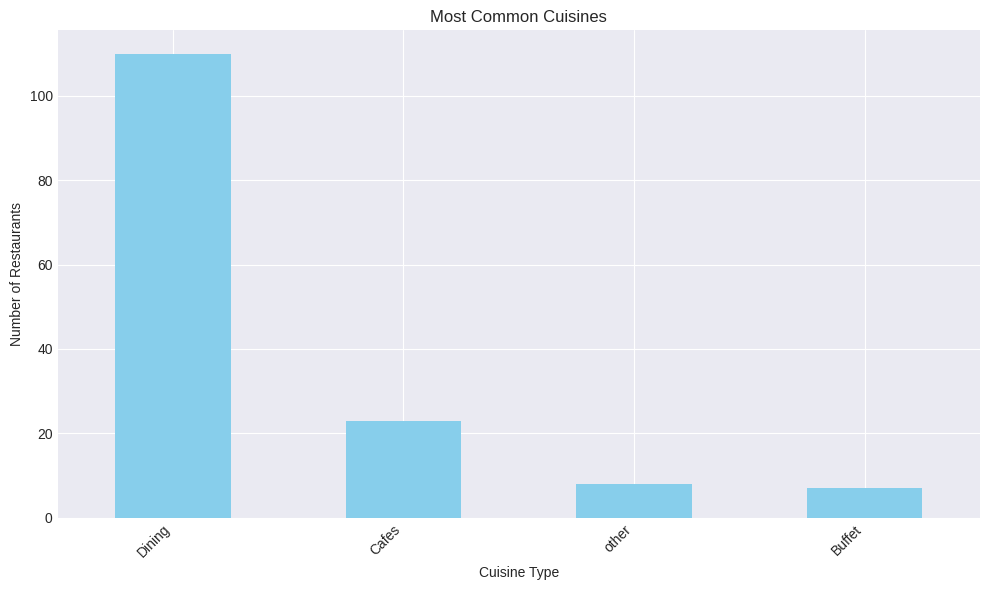

Bar chart for most common cuisines displayed.


In [26]:
import matplotlib.pyplot as plt

# Set up plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Bar chart for top cuisines
plt.figure(figsize=(10, 6))
most_common_cuisines.plot(kind='bar', color='skyblue')
plt.title('Most Common Cuisines')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar chart for most common cuisines displayed.")

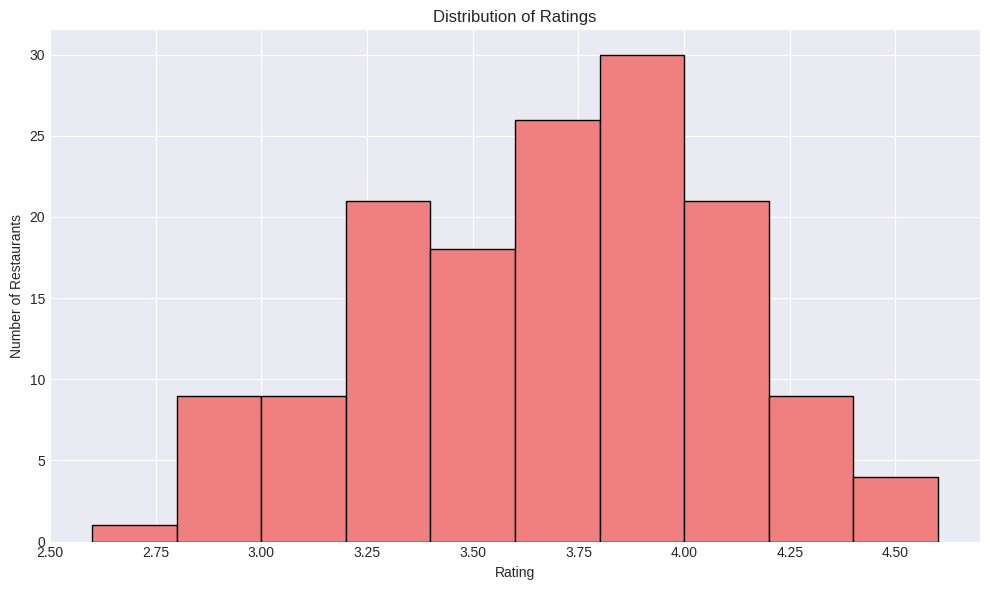

Histogram for rating distribution displayed.


In [27]:
# Histogram for ratings
plt.figure(figsize=(10, 6))
plt.hist(df['rate'], bins=10, color='lightcoral', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

print("Histogram for rating distribution displayed.")

In [28]:
# Bar chart for top locations
# As identified in EDA, location data is not available.
print("Cannot create a bar chart for top locations as location data is not available in the dataset.")

Cannot create a bar chart for top locations as location data is not available in the dataset.


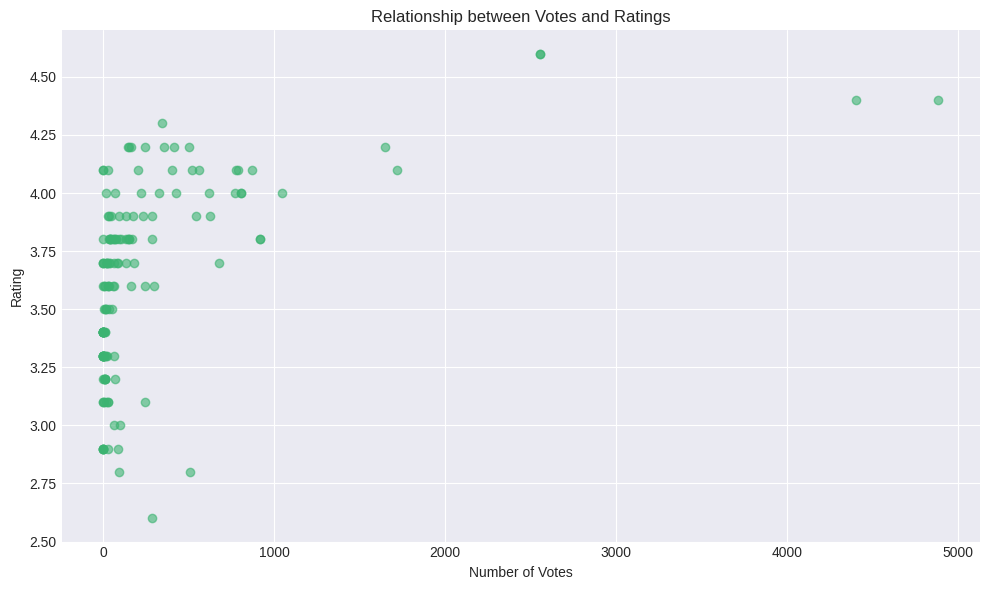

Scatter plot for votes vs ratings displayed.


In [29]:
# Scatter plot for votes vs ratings
plt.figure(figsize=(10, 6))
plt.scatter(df['votes'], df['rate'], alpha=0.6, color='mediumseagreen')
plt.title('Relationship between Votes and Ratings')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

print("Scatter plot for votes vs ratings displayed.")

## 5. Business Insights

Based on the Exploratory Data Analysis and visualizations, here are some practical business insights for Zomato:

### Insight 1: Dominance of Dining and Cafes

The dataset shows a clear prevalence of 'Dining' establishments and 'Cafes'. This indicates that these categories are core offerings and likely represent a significant portion of user searches and activity on the platform. Zomato should continue to optimize discovery and features for these dominant types, ensuring comprehensive listings and engaging content.

### Insight 2: Importance of High Ratings and Engagement

There's a positive correlation between the number of votes and ratings. Restaurants with more votes tend to have higher ratings, and the top-rated restaurants also have substantial vote counts. This signifies that user engagement (votes) is a strong indicator of perceived quality and popularity. Zomato can leverage this by promoting highly-voted, well-rated restaurants and encouraging users to leave reviews and ratings.

### Insight 3: Consistent Quality across Mid-Range Restaurants

The distribution of ratings suggests that many restaurants fall into a 'good' rather than 'excellent' category, with an average rating around 3.63. While there are top performers, the bulk of restaurants provide a satisfactory experience. This could indicate a large market segment for reliable, mid-range dining options, where consistency is key for customer retention.

### Insight 4: Pricing Strategy Opportunities

With an average cost for two people around ₹418, Zomato has an opportunity to cater to a broad middle-income segment. Understanding price sensitivity and offering features like filters for different price ranges or 'value for money' badges could enhance user experience and merchant success.

## 6. Recommendations

Based on the insights, here are data-driven recommendations for Zomato:

### Recommendation 1: Enhance User Engagement Features

Given the positive correlation between votes and ratings, Zomato should implement more prominent and gamified features to encourage users to rate and review restaurants. This could include personalized prompts, badges for active reviewers, or integrating review requests more seamlessly into the post-dining experience (e.g., after an online order or a table booking). Increased engagement directly translates to more valuable data and highlights quality establishments.

### Recommendation 2: Curated Collections for Dominant Categories

Since 'Dining' and 'Cafes' are dominant, Zomato should create highly curated collections, guides, and discovery features specifically for these categories. For example, 'Top 50 Cafes for Work', 'Best Dining Experiences for Couples', or 'Hidden Gems: Dining'. This would help users navigate the large number of options and find exactly what they're looking for within these popular segments.

### Recommendation 3: Develop a 'Consistency' Metric or Badge

For the large segment of restaurants providing 'good' rather than 'excellent' experiences, Zomato could introduce a 'Consistent Quality' metric or badge. This would highlight establishments that reliably deliver a satisfactory experience over time, even if they don't always hit the peak ratings. This could help build trust with users looking for dependable choices and offer a new recognition opportunity for merchants.

### Recommendation 4: Expand Location Data (if possible)

Although not available in this dataset, comprehensive location data is crucial for a food delivery and discovery platform. Zomato should prioritize acquiring and integrating granular location information for restaurants. This would enable highly relevant location-based searches, personalized recommendations, and efficient logistics for delivery services, significantly enhancing the user experience and operational efficiency.